# 0.0 Setting up Librarys and Device Configs

In [ ]:
!pip install pytorch_lightning
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F


from torchvision.transforms import ToTensor
from torch.utils.data import dataset, DataLoader

import torchvision.transforms as transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.models import resnet18
from timm.data.mixup import Mixup

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.8 MB/s eta 0:00:00


In [ ]:
torch.__version__

'2.10.0+cu128'

# 1.0 Device Agnositic Code

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# 2.0 Downloading Data From Kaggle

In [ ]:
from pathlib import Path
import shutil
import kagglehub

# Download dataset
source_path = Path(kagglehub.dataset_download("sumn2u/garbage-classification-v2"))

# Target directory
target_path = Path("data/garbage")
target_path.mkdir(parents=True, exist_ok=True)

# Copy everything
shutil.copytree(source_path, target_path, dirs_exist_ok=True)

print("Dataset copied to:", target_path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Dataset copied to: data/garbage


# installing split-folders lib

In [ ]:
!pip install split-folders

## 2.1 Splitting Folders into Proper Train, Test. skipped val for now

In [ ]:
import splitfolders
path = "data/garbage/original"
splitfolders.ratio(
    input=path,              # your dataset folder
    output="data_split",     # new folder
    seed=42,                # reproducible
    ratio=(0.8, 0.2)   # train, val, test
)


Copying files: 12259 files [00:04, 2533.12 files/s]


## 2.2 Setup Train_dir, test_dir paths

In [ ]:
train_dir = "/data_split/train"
test_dir = "/data_split/val"

## 2.3 Loading random image from our dataset

Random image path: data_split/val/paper/paper_79.jpg
Image class: paper
Image height: 340
Image width: 400


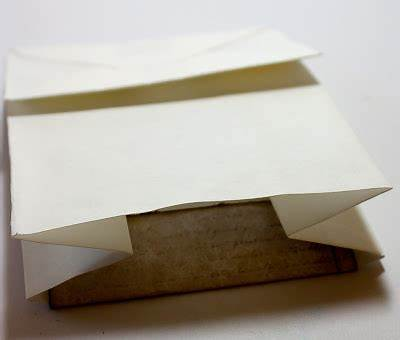

In [ ]:
import random
from PIL import Image
from pathlib import Path # Import Path

image_path = Path('data_split') # Convert to Path object
random.seed(42)
# Updated glob pattern to account for nested class folders
image_path_list = list(image_path.glob('*/*/*.jpg'))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

# printing metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

### visulizing with matplot

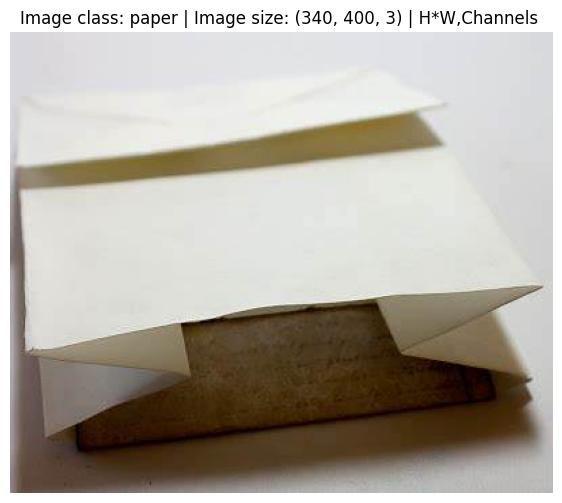

In [ ]:
img_as_arr = np.asarray(img)
plt.figure(figsize=(7, 7))
plt.imshow(img_as_arr)
plt.title(f"Image class: {image_class} | Image size: {img_as_arr.shape} | H*W,Channels ")
plt.axis(False)
plt.show()

# 3.0 Transforming our data

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    # Ensures all images same size → required for batching

    transforms.RandomHorizontalFlip(p=0.5),
    # Simulates left-right variation

    transforms.RandomRotation(10),
    # Small rotation → real-world noise

    transforms.RandAugment(num_ops=2, magnitude=9),
    #  SOTA: random strong augmentations

    transforms.ToTensor(),
    # Converts image → tensor (needed for PyTorch)

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    # Standard normalization → stable training
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

## 3.1 Visualizing Our Transformation

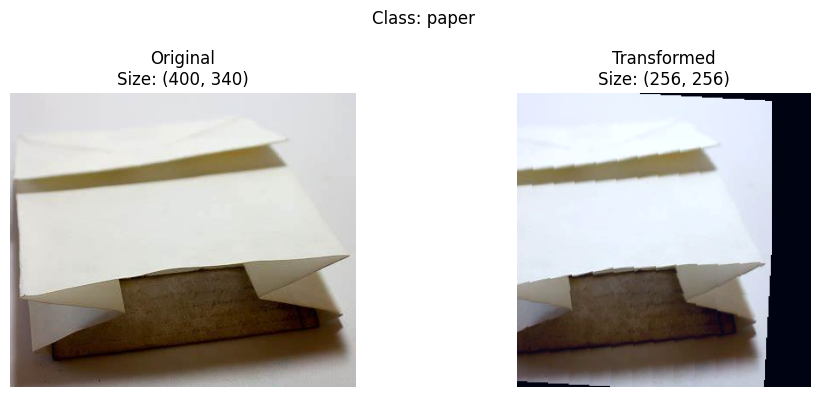

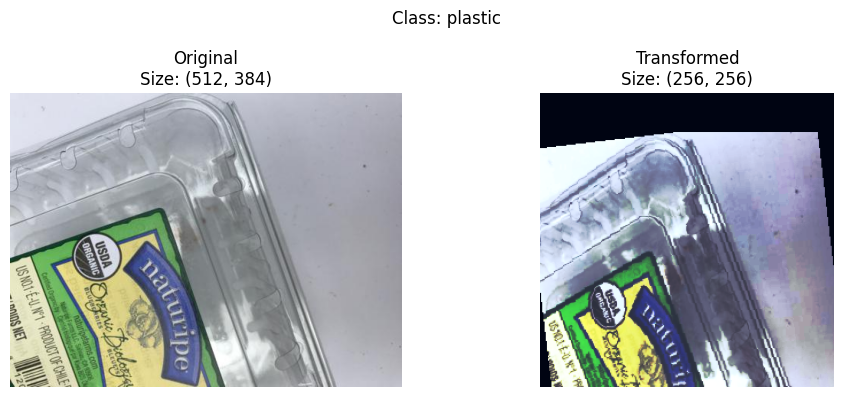

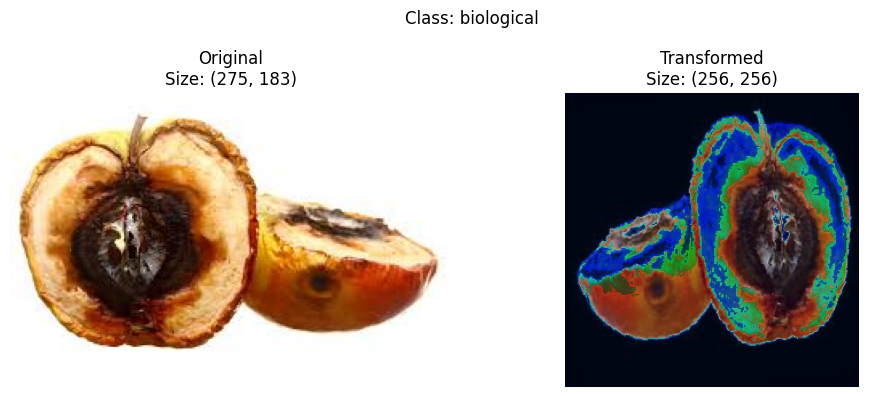

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_transformed_image(image_path_list, n=3, seed=None):
    if seed is not None:
        random.seed(seed)

    random_image_paths = random.sample(image_path_list, n)

    for image_path in random_image_paths:
        with Image.open(image_path).convert("RGB") as img:

            fig, ax = plt.subplots(1, 2, figsize=(10, 4))

            # Original image
            ax[0].imshow(img)
            ax[0].set_title(f"Original\nSize: {img.size}")
            ax[0].axis("off")

            # Transformed image
            transformed = train_transform(img)
            transformed = transformed.permute(1, 2, 0)

            #  undo normalization for visualization
            transformed = transformed * 0.229 + 0.485
            transformed = transformed.clamp(0, 1)

            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed\nSize: {tuple(transformed.shape[:2])}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}")
            plt.tight_layout()
            plt.show()

plot_transformed_image(image_path_list, 3, 42)

# 4 Loading dataset using ImageFolder

In [ ]:
from torchvision import datasets

# Correcting the paths to be relative
train_dir = "data_split/train"
test_dir = "data_split/val"

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 9802
    Root location: data_split/train
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 2457
    Root location: data_split/val
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
           )


In [ ]:
class_names = train_data.classes
class_names

['battery',
 'biological',
 'cardboard',
 'clothes',
 'glass',
 'metal',
 'paper',
 'plastic',
 'shoes',
 'trash']

In [ ]:
class_idx = train_data.class_to_idx
class_idx

{'battery': 0,
 'biological': 1,
 'cardboard': 2,
 'clothes': 3,
 'glass': 4,
 'metal': 5,
 'paper': 6,
 'plastic': 7,
 'shoes': 8,
 'trash': 9}

In [ ]:
# len of our train
len(train_data), len(test_data)

(9802, 2457)

In [ ]:
import torch

# Get the first 5 image-label pairs
samples = [train_data[i] for i in range(5)]

# Extract only the image tensors
image_tensors = [sample[0] for sample in samples]

# Stack them into a single batch tensor
batch_tensor = torch.stack(image_tensors)

# Convert to NumPy array and print its shape
print(f"Shape of 5 image tensors as a batch: {batch_tensor.shape}")
print(f"Shape of the NumPy array: {batch_tensor.numpy().shape}")


Shape of 5 image tensors as a batch: torch.Size([5, 3, 256, 256])
Shape of the NumPy array: (5, 3, 256, 256)


In [ ]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image shape: {img.shape}")
print(f"labe: {class_names[label]}")

Image shape: torch.Size([3, 256, 256])
labe: battery


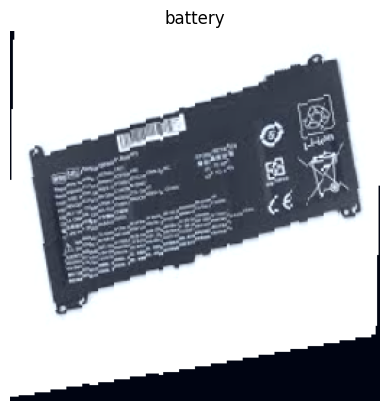

In [ ]:
# visualizing out image
transformed = img
transformed = transformed.permute(1, 2, 0)

#  undo normalization for visualization
transformed = transformed * 0.229 + 0.485
transformed = transformed.clamp(0, 1)
plt.imshow(transformed)
plt.title(class_names[label])
plt.axis(False)
plt.show()

# 5.0 Creating Our Loaders

In [ ]:
# Config out loaders
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

In [ ]:
img, label = next(iter(train_loader))
img.shape, label

(torch.Size([32, 3, 256, 256]),
 tensor([8, 3, 6, 1, 4, 4, 9, 8, 1, 7, 2, 3, 4, 0, 4, 5, 3, 3, 4, 3, 1, 3, 4, 4,
         5, 6, 7, 4, 4, 5, 7, 9]))

# 6.0 Creating our Pytorch Lighting Framework, for Auto Training.

## 6.1 Pytorch Augmentation(CutMix)
 Why here?
Needs batch of images
Cannot be inside transforms

In [ ]:
mixup_fn = Mixup(
    mixup_alpha=0.0,    # disable mixup
    cutmix_alpha=1.0,   # enable CutMix
    prob=1.0            # always apply
)

# 6.2 Resnet Pretrained

In [ ]:
class WasteClassifier(pl.LightningModule):

    def __init__(self, num_classes=10, lr=1e-3):
      super().__init__()

      self.lr = lr

        #  Pretrained CNN (much better than custom)
      self.model = resnet18(weights="DEFAULT")

        # Replace final layer
      self.model.fc = nn.Linear(512, num_classes)

    def forward(self, x):
      return self.model(x)


    def training_step(self, batch, batch_idx):
      x, y = batch

      # Apply CutMix here
      x, y = mixup_fn(x, y)

      logits = self(x)

      loss = F.cross_entropy(logits, y.argmax(dim=1))
      # Works with soft labels (important!)

      preds = torch.argmax(logits, dim=1)

      # Accuracy ONLY valid if labels are hard
      if y.ndim == 1:
        acc = (preds == y).float().mean()
        self.log("train_acc", acc, prog_bar=True)

        self.log("train_loss", loss, prog_bar=True)
      return loss

    def validation_step(self, batch, batch_idx):
      x, y = batch

      logits = self(x)

      loss = F.cross_entropy(logits, y)

      preds = torch.argmax(logits, dim=1)
      acc = (preds == y).float().mean()

      self.log("val_loss", loss, prog_bar=True)
      self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
      optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
      scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=2)

      return {
        "optimizer": optimizer,
        "lr_scheduler": scheduler,
        "monitor": "val_loss"}

# 7.0 Training Loop

In [ ]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3
)

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    precision=16,         #  faster training on T4
    callbacks=[early_stop, checkpoint]
)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
# Instantiate the model
model = WasteClassifier(num_classes=len(class_names), lr=1e-3)

# Start training
trainer.fit(model, train_loader, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet │ 11.2 M │ train │     0 │
└───┴───────┴────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

# Save the model weights

In [ ]:
torch.save(model.state_dict(), "model_weights.pth")

#

# 8.0 Downloading external Dataset

In [ ]:
# downloading the external dataset from github
!wget https://github.com/utkarsh820/test_waste_garbage_ext.git


--2026-03-26 13:42:18--  https://github.com/utkarsh820/test_waste_garbage_ext.git
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/utkarsh820/test_waste_garbage_ext [following]
--2026-03-26 13:42:18--  https://github.com/utkarsh820/test_waste_garbage_ext
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘test_waste_garbage_ext.git’

test_waste_garbage_     [  <=>               ] 237.40K  1.00MB/s    in 0.2s    

2026-03-26 13:42:18 (1.00 MB/s) - ‘test_waste_garbage_ext.git’ saved [243102]



# Inferencing on external images

In [ ]:
!unzip test_waste_garbage_ext.zip

Archive:  test_waste_garbage_ext.zip
replace test_waste_garbage_ext/battery.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: test_waste_garbage_ext/battery.png  
  inflating: test_waste_garbage_ext/biological.jpg  
  inflating: test_waste_garbage_ext/cardboard.jpeg  
  inflating: test_waste_garbage_ext/clothes.jpg  
  inflating: test_waste_garbage_ext/glass.jpg  
  inflating: test_waste_garbage_ext/metal.jpg  
  inflating: test_waste_garbage_ext/plastic.jpg  
  inflating: test_waste_garbage_ext/shoes.jpg  
  inflating: test_waste_garbage_ext/trash.jpg  


In [ ]:
from PIL import Image
from torchvision import transforms

# Must match the training transformations
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import os
from torch.utils.data import Dataset

# Custom Dataset to handle a flat folder of images
class SimpleImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Filter for image files only to avoid .ipynb_checkpoints or other system files
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

ext_test = "/content/test_waste_garbage_ext"
ext_data = SimpleImageDataset(ext_test, transform=transform)
ext_loader = DataLoader(ext_data, batch_size=1, shuffle=False)

print(f"Found {len(ext_data)} images for inference.")

Found 9 images for inference.


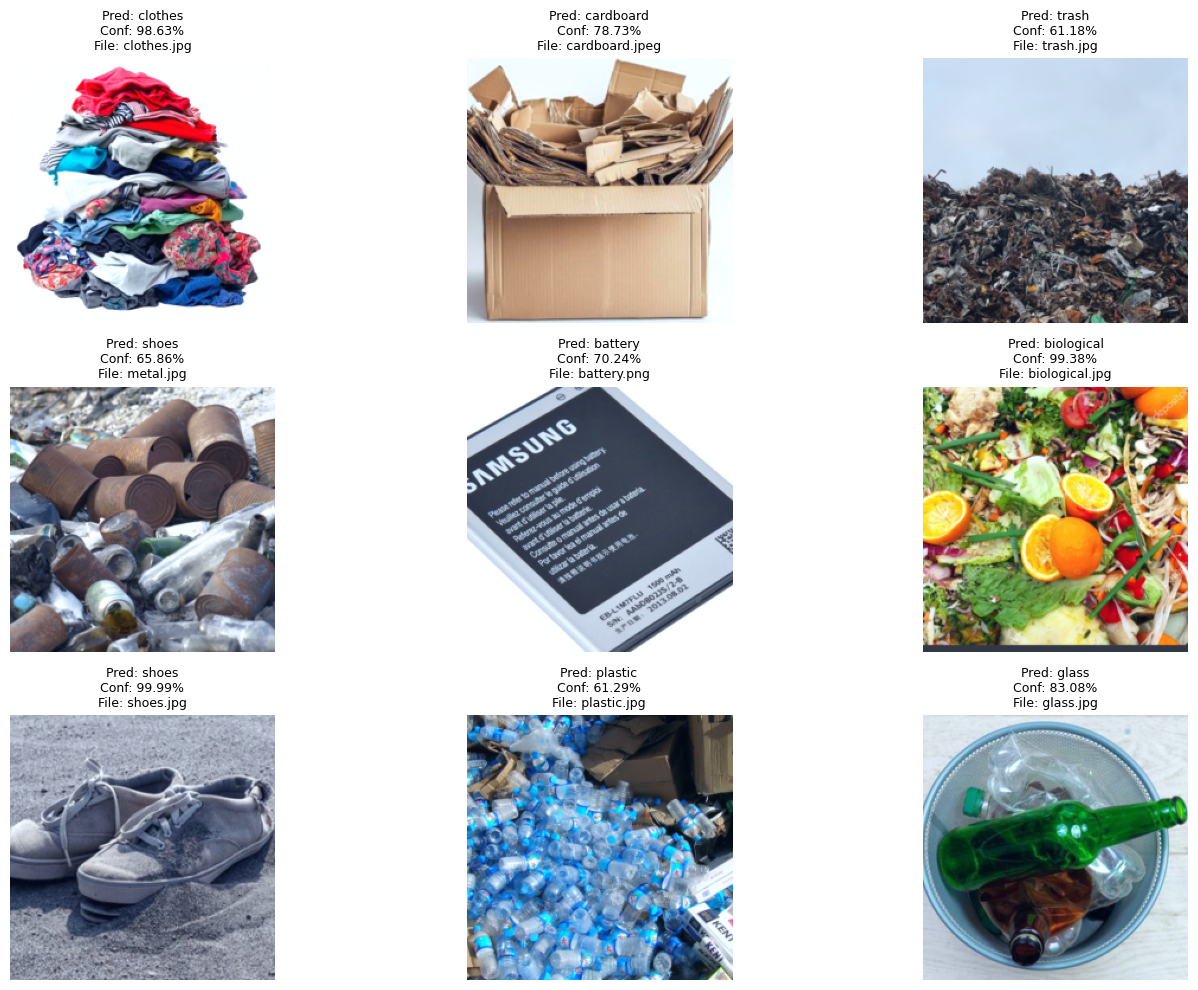

In [ ]:
model.eval()
model.to(device)

plt.figure(figsize=(15, 10))

# Loop through the entire loader to predict all images
for i, (img_tensor, filename) in enumerate(ext_loader):
    with torch.no_grad():
        logits = model(img_tensor.to(device))
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    plt.subplot(3, 3, i + 1)
    # Undo normalization for visualization
    viz_img = img_tensor[0].permute(1, 2, 0) * 0.229 + 0.485
    plt.imshow(viz_img.clamp(0, 1))
    plt.title(f"Pred: {class_names[pred_idx]}\nConf: {confidence:.2%}\nFile: {filename[0]}", fontsize=9)
    plt.axis(False)

plt.tight_layout()
plt.show()

# The external image was collected from google search randomly, only thing i done is correction of format & transformation.

## also i don't own this images. i just used for demonstration